In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [3]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.to_csv("insurance.csv", index=False)
print(df.shape)
print(df.head())

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:
# Basic checks
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  13

In [5]:
#converting charges into categories
def categorize_premium(charges):
    if charges < 5000:
        return "low"
    elif charges < 15000:
        return "medium"
    else:
        return "high"
df["premium_category"] = df["charges"].apply(categorize_premium)  
print(df["premium_category"].value_counts())

premium_category
medium    621
low       359
high      358
Name: count, dtype: int64


C:\Users\bhoom\AppData\Local\Temp\ipykernel_9240\1069914047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


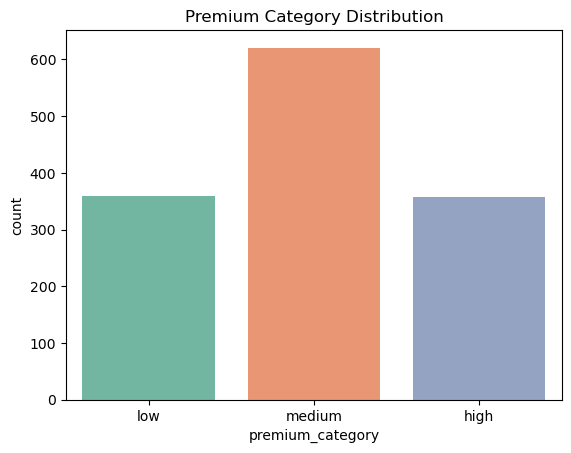

In [6]:
#plot of categorys
sns.countplot(
    data = df,
    x = "premium_category",
    order = ["low","medium","high"],
    palette = "Set2"
)
plt.title("Premium Category Distribution")
plt.show()

C:\Users\bhoom\AppData\Local\Temp\ipykernel_9240\3761805627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


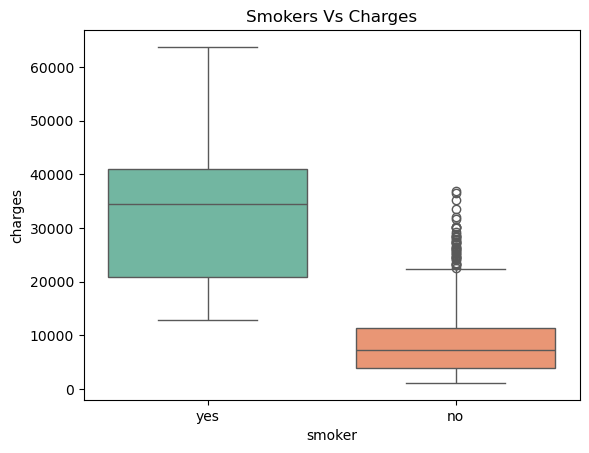

In [7]:
# do smakers pays more
sns.boxplot(
    x = "smoker",
    y = "charges",
    data = df,
    palette = "Set2"
)
plt.title("Smokers Vs Charges")
plt.show()

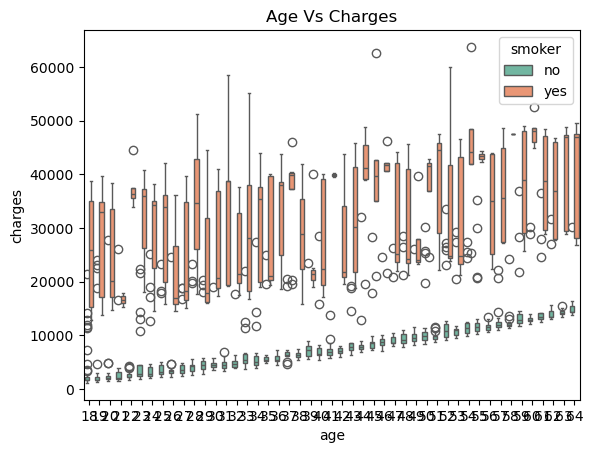

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [8]:
#does age affects charges
sns.boxplot(
    data = df,
    x = "age",
    y = "charges",
    hue = "smoker",
    palette = "Set2"
)
plt.title("Age Vs Charges")
plt.show()
plt.tight_layout

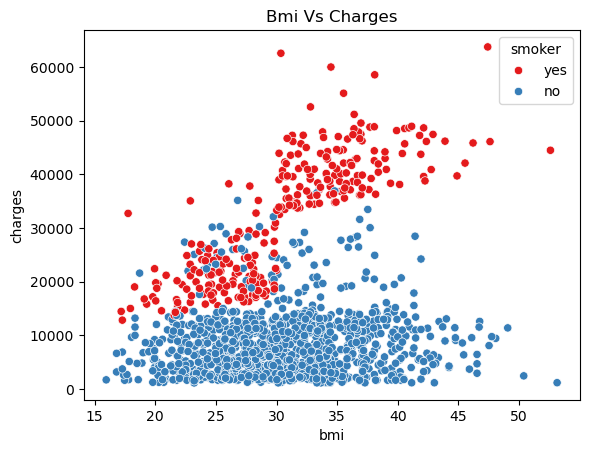

In [9]:
#how does bmi affects
sns.scatterplot(
    x = "bmi",
    y = "charges",
    data = df,
    palette = "Set1",
    hue = "smoker"
)
plt.title("Bmi Vs Charges")
plt.show()

In [10]:
df["smoker_obese"] = ((df["smoker"] == "yes") & df["bmi"] >= 30).astype(int)

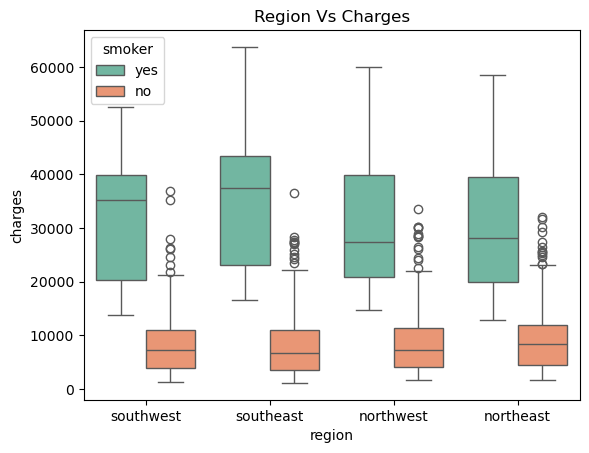

In [11]:
# does region affects charges
sns.boxplot(
    data = df,
    x = "region",
    y = "charges",
    palette = "Set2",
    hue = "smoker"
)
plt.title("Region Vs Charges")
plt.show()

In [12]:
#encoding
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le =  LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df = pd.get_dummies(df, columns = ["region"])
for col in df.select_dtypes(bool).columns:
    df[col] = df[col].astype(int)


In [13]:
df.head()

,age,sex,bmi,children,smoker,charges,premium_category,smoker_obese,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,high,0,0,0,0,1
1,18,1,33.770,1,0,1725.55230,low,0,0,0,1,0
2,28,1,33.000,3,0,4449.46200,low,0,0,0,1,0
3,33,1,22.705,0,0,21984.47061,high,0,0,1,0,0
4,32,1,28.880,0,0,3866.85520,low,0,0,1,0,0


In [15]:
df.to_csv("insurance_encoded.csv", index = False)
print("saved")

saved
